## Electrode Mutual Information Analysis

**Overview**
- Mutual Information analysis for the all 192 electrodes using the average firing rate for individual trials from the handwriting BCI data set. 
- The notebook represents the MI calculations as a heatmap spatially mapped to the electrodes position on the probe.
- The notebook also contains code for a firing rate animation using the first 100 trials from the data set.

**Limitations**
- The notebook did not account for sample size bias in the mutual information calculations.

This code was written by Rob Lamprecht.

_Note: Github Copilot powered by Claude 3.5 and Claude 3.7 sonnet was used to assist in the generation of this code. Relevant prompts are included beaneath the cells where AI was used_

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
import scipy.io as sio


In [11]:
# Load the data
avgFiring = sio.loadmat(r'MIdatasets\trialavgsforMI.mat')
TargetChar = sio.loadmat(r'MIdatasets\letteridsforMI.mat')

_Note: Claude was used here_  
"Load .mat files in python"

In [12]:
print(avgFiring.keys())
print(TargetChar.keys())

dict_keys(['__header__', '__version__', '__globals__', 'trialavgsforMI'])
dict_keys(['__header__', '__version__', '__globals__', 'letteridsforMI'])


In [13]:
print(avgFiring['trialavgsforMI'])
print(len(TargetChar['letteridsforMI']))
print(len(avgFiring['trialavgsforMI']))

[[0.16901408 0.19014085 0.09859155 ... 0.27464789 0.11971831 0.54929577]
 [0.21830986 0.16197183 0.12676056 ... 0.3028169  0.14788732 0.57042254]
 [0.21830986 0.21126761 0.17605634 ... 0.29577465 0.15492958 0.55633803]
 ...
 [0.4084507  0.19014085 0.20422535 ... 0.45774648 0.26760563 0.51408451]
 [0.33098592 0.16901408 0.16197183 ... 0.35915493 0.1971831  0.5       ]
 [0.48591549 0.26056338 0.26056338 ... 0.32394366 0.23943662 0.42253521]]
837
837


In [14]:
def orderCharArray (charArray):
  TargetChar = []
  for i in range(len(charArray)):
    TargetChar.append(charArray[i][0][0])
  return TargetChar

In [15]:
TargetChar = orderCharArray(TargetChar['letteridsforMI'])

print(avgFiring['trialavgsforMI'])
print(TargetChar)

[[0.16901408 0.19014085 0.09859155 ... 0.27464789 0.11971831 0.54929577]
 [0.21830986 0.16197183 0.12676056 ... 0.3028169  0.14788732 0.57042254]
 [0.21830986 0.21126761 0.17605634 ... 0.29577465 0.15492958 0.55633803]
 ...
 [0.4084507  0.19014085 0.20422535 ... 0.45774648 0.26760563 0.51408451]
 [0.33098592 0.16901408 0.16197183 ... 0.35915493 0.1971831  0.5       ]
 [0.48591549 0.26056338 0.26056338 ... 0.32394366 0.23943662 0.42253521]]
[np.str_('a'), np.str_('a'), np.str_('a'), np.str_('a'), np.str_('a'), np.str_('a'), np.str_('a'), np.str_('a'), np.str_('a'), np.str_('a'), np.str_('a'), np.str_('a'), np.str_('a'), np.str_('a'), np.str_('a'), np.str_('a'), np.str_('a'), np.str_('a'), np.str_('a'), np.str_('a'), np.str_('a'), np.str_('a'), np.str_('a'), np.str_('a'), np.str_('a'), np.str_('a'), np.str_('a'), np.str_('b'), np.str_('b'), np.str_('b'), np.str_('b'), np.str_('b'), np.str_('b'), np.str_('b'), np.str_('b'), np.str_('b'), np.str_('b'), np.str_('b'), np.str_('b'), np.str_('

In [16]:
# convert target characters to regular strings for the classifier
TargetChar = np.array([str(x) for x in TargetChar])
print(TargetChar)

['a' 'a' 'a' 'a' 'a' 'a' 'a' 'a' 'a' 'a' 'a' 'a' 'a' 'a' 'a' 'a' 'a' 'a'
 'a' 'a' 'a' 'a' 'a' 'a' 'a' 'a' 'a' 'b' 'b' 'b' 'b' 'b' 'b' 'b' 'b' 'b'
 'b' 'b' 'b' 'b' 'b' 'b' 'b' 'b' 'b' 'b' 'b' 'b' 'b' 'b' 'b' 'b' 'b' 'b'
 'c' 'c' 'c' 'c' 'c' 'c' 'c' 'c' 'c' 'c' 'c' 'c' 'c' 'c' 'c' 'c' 'c' 'c'
 'c' 'c' 'c' 'c' 'c' 'c' 'c' 'c' 'c' 'd' 'd' 'd' 'd' 'd' 'd' 'd' 'd' 'd'
 'd' 'd' 'd' 'd' 'd' 'd' 'd' 'd' 'd' 'd' 'd' 'd' 'd' 'd' 'd' 'd' 'd' 'd'
 'e' 'e' 'e' 'e' 'e' 'e' 'e' 'e' 'e' 'e' 'e' 'e' 'e' 'e' 'e' 'e' 'e' 'e'
 'e' 'e' 'e' 'e' 'e' 'e' 'e' 'e' 'e' 'f' 'f' 'f' 'f' 'f' 'f' 'f' 'f' 'f'
 'f' 'f' 'f' 'f' 'f' 'f' 'f' 'f' 'f' 'f' 'f' 'f' 'f' 'f' 'f' 'f' 'f' 'f'
 'g' 'g' 'g' 'g' 'g' 'g' 'g' 'g' 'g' 'g' 'g' 'g' 'g' 'g' 'g' 'g' 'g' 'g'
 'g' 'g' 'g' 'g' 'g' 'g' 'g' 'g' 'g' 'h' 'h' 'h' 'h' 'h' 'h' 'h' 'h' 'h'
 'h' 'h' 'h' 'h' 'h' 'h' 'h' 'h' 'h' 'h' 'h' 'h' 'h' 'h' 'h' 'h' 'h' 'h'
 'i' 'i' 'i' 'i' 'i' 'i' 'i' 'i' 'i' 'i' 'i' 'i' 'i' 'i' 'i' 'i' 'i' 'i'
 'i' 'i' 'i' 'i' 'i' 'i' 'i' 'i' 'i' 'j' 'j' 'j' 'j

_Note: Claude was used here._  
Prompt:
" I have a nested array where each value is np.str__('a') for some character, I just want the character"

In [22]:
# Calculate mutual information scores
avgFiring = np.array(avgFiring['trialavgsforMI'])
mutual_info_scores = mutual_info_classif(avgFiring, TargetChar)
print(mutual_info_scores)

[0.05673535 0.10500846 0.01959723 0.         0.00682964 0.
 0.10751603 0.27407697 0.08919301 0.06906249 0.02286764 0.07482607
 0.15839197 0.09955782 0.         0.02233172 0.12104271 0.
 0.         0.         0.         0.04153947 0.14344096 0.04910161
 0.         0.         0.04484715 0.05285344 0.         0.0826105
 0.00624846 0.10697353 0.24686127 0.31839441 0.28293159 0.18742005
 0.17916248 0.21558102 0.06393779 0.05118031 0.         0.
 0.02309676 0.03211294 0.         0.02726727 0.01217611 0.01321779
 0.00848491 0.         0.02532336 0.         0.04167199 0.0213197
 0.00158537 0.04493211 0.02822271 0.         0.         0.00828283
 0.04962904 0.00938483 0.         0.         0.05262059 0.01100899
 0.05284129 0.08643903 0.31335554 0.06891816 0.07167923 0.32932629
 0.02273788 0.00738636 0.         0.01201929 0.02286876 0.
 0.02805152 0.         0.         0.06679861 0.         0.
 0.         0.         0.         0.         0.00670123 0.
 0.         0.0148956  0.         0.         

_Note: Claude was used here_  
Prompts:  
"Overview of the mutual information classifier from sklearn"

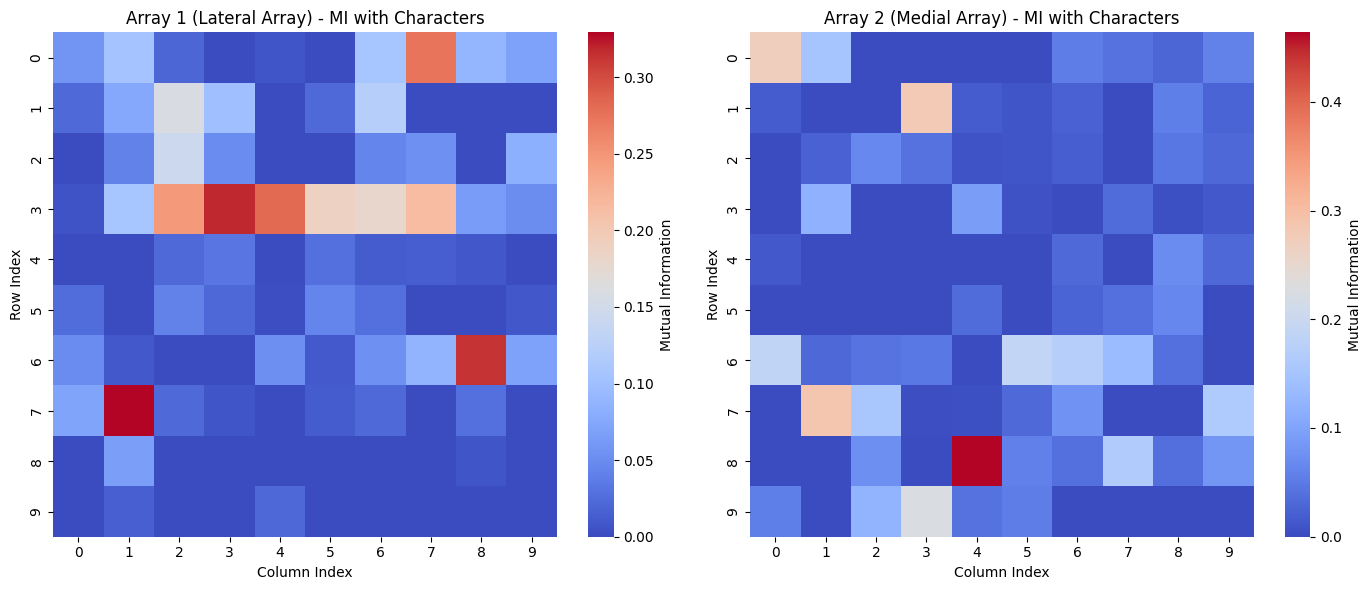

In [25]:
import seaborn as sns
def plot_simplified_mi_heatmap(mutual_info_scores, num_arrays=2):
    electrodes_per_array = len(mutual_info_scores) // num_arrays

    # Reshape to a grid for visualization corners will be empty
    grid_size = int(np.ceil(np.sqrt(electrodes_per_array)))

    array1_mi = np.zeros((grid_size, grid_size))
    array2_mi = np.zeros((grid_size, grid_size))

    # Array one setup
    for i in range(min(electrodes_per_array, len(mutual_info_scores))):
        row = i // grid_size
        col = i % grid_size
        array1_mi[row, col] = mutual_info_scores[i]

    # Same thing for array two
    for i in range(min(electrodes_per_array, len(mutual_info_scores) - electrodes_per_array)):
        row = i // grid_size
        col = i % grid_size
        array2_mi[row, col] = mutual_info_scores[i + electrodes_per_array]

    # Create plot
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))

    # Plot first array
    sns.heatmap(array1_mi, ax=axs[0], cmap="coolwarm",
               cbar_kws={'label': 'Mutual Information'})
    axs[0].set_title('Array 1 (Lateral Array) - MI with Characters')
    axs[0].set_xlabel('Column Index')
    axs[0].set_ylabel('Row Index')

    # Plot second array
    sns.heatmap(array2_mi, ax=axs[1], cmap="coolwarm",
               cbar_kws={'label': 'Mutual Information'})
    axs[1].set_title('Array 2 (Medial Array) - MI with Characters')
    axs[1].set_xlabel('Column Index')
    axs[1].set_ylabel('Row Index')

    plt.tight_layout()
    plt.show()

    return fig

fig = plot_simplified_mi_heatmap(mutual_info_scores)

_Note: Claude was used here_  
Prompts:  
"Plot two heatmaps on the same figure in python"  
"Seaborn heatmap overview"

In [ ]:
# Load the Electrode Geometry Data
file_path = 'MIdatasets\Copy of t5.2019.05.08_singleLetters.mat'
mat_data = sio.loadmat(file_path)

print(mat_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'neuralActivityCube_doNothing', 'neuralActivityCube_a', 'neuralActivityCube_b', 'neuralActivityCube_c', 'neuralActivityCube_d', 'neuralActivityCube_t', 'neuralActivityCube_m', 'neuralActivityCube_o', 'neuralActivityCube_e', 'neuralActivityCube_f', 'neuralActivityCube_g', 'neuralActivityCube_h', 'neuralActivityCube_i', 'neuralActivityCube_j', 'neuralActivityCube_k', 'neuralActivityCube_l', 'neuralActivityCube_n', 'neuralActivityCube_p', 'neuralActivityCube_q', 'neuralActivityCube_r', 'neuralActivityCube_s', 'neuralActivityCube_u', 'neuralActivityCube_v', 'neuralActivityCube_w', 'neuralActivityCube_x', 'neuralActivityCube_y', 'neuralActivityCube_z', 'neuralActivityCube_greaterThan', 'neuralActivityCube_comma', 'neuralActivityCube_apostrophe', 'neuralActivityCube_tilde', 'neuralActivityCube_questionMark', 'neuralActivityTimeSeries', 'clockTimeSeries', 'blockNumsTimeSeries', 'blockList', 'blockStartDates', 'goPeriodOnsetTimeBin', 'dela

In [ ]:
array_geometry_map = mat_data['arrayGeometryMap']

In [ ]:
print(array_geometry_map)
x = len(array_geometry_map[1])
y = len(array_geometry_map)
print(x)
print(y)

[[ 0 79 77 75 73 71 69 67 65  0]
 [81 80 78 76 74 72 70 68 66  2]
 [83 84 82 45 41 39 37 35 33  1]
 [85 86 49 47 43 40 38 36 34  3]
 [88 87 53 51 44 42 48  5  7  4]
 [90 89 55 56 46 50 15 17  9  6]
 [92 91 57 58 52 54 19 13 11  8]
 [93 94 59 60 62 21 25 23 12 10]
 [96 63 61 64 31 29 27 20 16 14]
 [ 0 95 32 30 28 26 24 22 18  0]]
10
10


In [ ]:
def look_up_position(array_geometry_map, electrode_idx):
    for i in range(array_geometry_map.shape[0]):
        for j in range(array_geometry_map.shape[1]):
            if array_geometry_map[i, j] == electrode_idx + 1:
                return i, j
    return None

def map_MI_to_Array_Position(mutual_info, array_geometry_map, grid_size = 10):
  # Create two empty 10 x 10 grids
  array1_mi = np.zeros((grid_size, grid_size))
  array2_mi = np.zeros((grid_size, grid_size))

  #Split mutual_info grid into two arrays
  #First 96 elements will be Array 1 : Lateral Array
  #Last 96 elements will be Array 2 : Medial Array

  tmpArray1 = mutual_info[:96]
  tmpArray2 = mutual_info[96:]

  # Look up i and j values for each index
  for i in range(len(tmpArray1)):
    row, col = look_up_position(array_geometry_map, i)
    array1_mi[row, col] = tmpArray1[i]
  for i in range(len(tmpArray2)):
    row, col = look_up_position(array_geometry_map, i)
    array2_mi[row, col] = tmpArray2[i]

  return array1_mi, array2_mi

_Note: Claude was used here_  
Prompts:
"Help debug this code snippet"

In [26]:
def plot_electrode_heatMap(array1, array2, title = "Mutual Information"):
    # Create the figure and axes
    fig, axs = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(title, fontsize=16)
    # Find global min and max for heat bar scaling
    vmin = min(np.min(array1_mi), np.min(array2_mi))
    vmax = max(np.max(array1_mi), np.max(array2_mi))

    # Plot first array (lateral array)
    cmap = sns.color_palette("coolwarm", as_cmap=True)
    sns.heatmap(array1_mi, ax=axs[0], cmap=cmap,
               cbar_kws={'label': 'Mutual Information'},
                vmin=vmin, vmax=vmax)
    axs[0].set_title('Array 1 (Lateral Array)', fontsize=14)
    axs[0].set_xlabel('Columns (Medial-Lateral)', fontsize=12)
    axs[0].set_ylabel('Rows (Anterior-Posterior)', fontsize=12)

    # Plot second array (medial array)
    sns.heatmap(array2_mi, ax=axs[1], cmap=cmap,
               cbar_kws={'label': 'Mutual Information'},
                vmin=vmin, vmax=vmax)
    axs[1].set_title('Array 2 (Medial Array)', fontsize=14)
    axs[1].set_xlabel('Columns (Medial-Lateral)', fontsize=12)
    axs[1].set_ylabel('Rows (Anterior-Posterior)', fontsize=12)

    plt.tight_layout(rect=[0, 0, 1, 0.96]) 

    return fig, axs


_Note: Claude was used here_  
Prompts:  
"Find the max and min of a numpy array"


In [27]:
from collections import Counter

char_counts = Counter(TargetChar)
char_counts

Counter({np.str_('a'): 27,
         np.str_('b'): 27,
         np.str_('c'): 27,
         np.str_('d'): 27,
         np.str_('e'): 27,
         np.str_('f'): 27,
         np.str_('g'): 27,
         np.str_('h'): 27,
         np.str_('i'): 27,
         np.str_('j'): 27,
         np.str_('k'): 27,
         np.str_('l'): 27,
         np.str_('m'): 27,
         np.str_('n'): 27,
         np.str_('o'): 27,
         np.str_('p'): 27,
         np.str_('q'): 27,
         np.str_('r'): 27,
         np.str_('s'): 27,
         np.str_('t'): 27,
         np.str_('u'): 27,
         np.str_('v'): 27,
         np.str_('w'): 27,
         np.str_('x'): 27,
         np.str_('y'): 27,
         np.str_('z'): 27,
         np.str_('greaterThan'): 27,
         np.str_('comma'): 27,
         np.str_('apostrophe'): 27,
         np.str_('tilde'): 27,
         np.str_('questionMark'): 27})

_Note: Claude was used here_  
Prompt:  
"count how many times each character appears in TargetChar"

(<Figure size 1600x700 with 4 Axes>,
 array([<Axes: title={'center': 'Array 1 (Lateral Array)'}, xlabel='Columns (Medial-Lateral)', ylabel='Rows (Anterior-Posterior)'>,
        <Axes: title={'center': 'Array 2 (Medial Array)'}, xlabel='Columns (Medial-Lateral)', ylabel='Rows (Anterior-Posterior)'>],
       dtype=object))

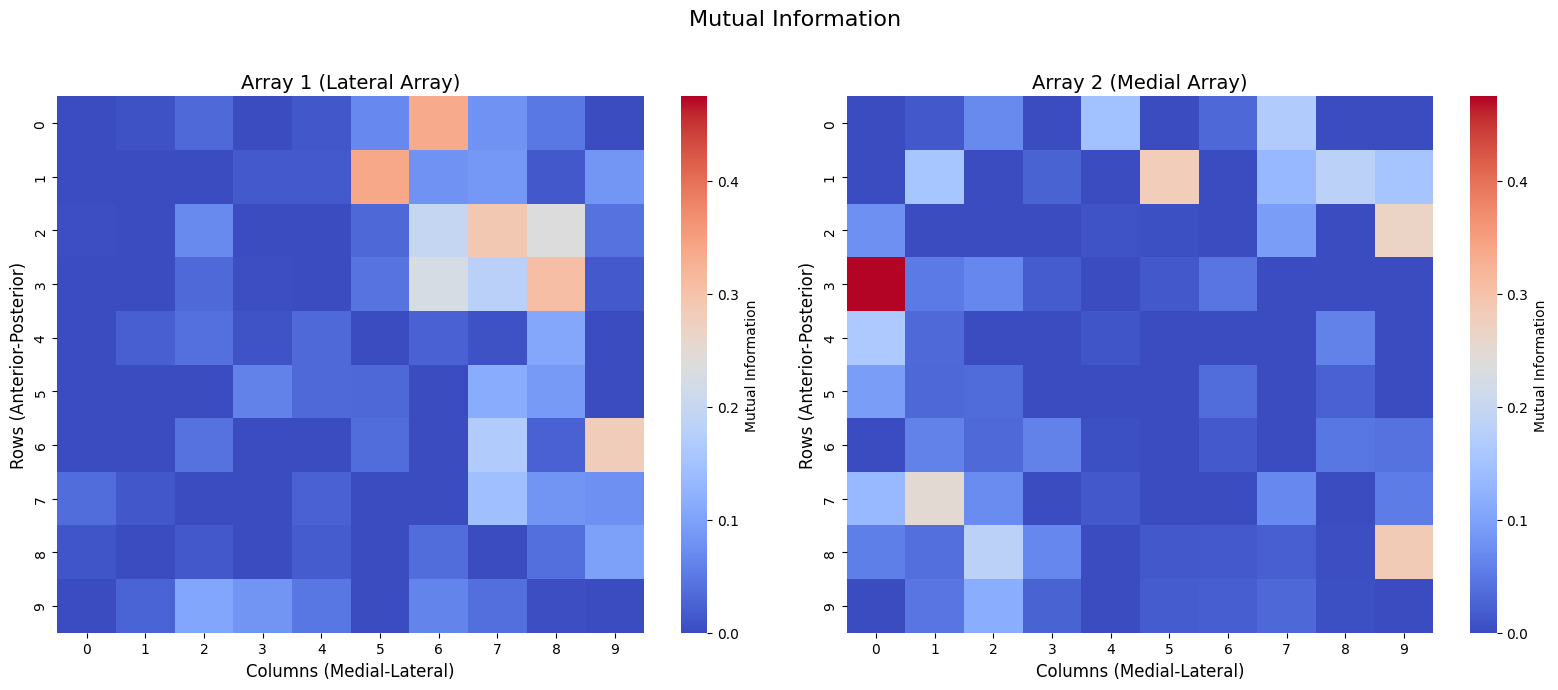

In [ ]:
array1_mi, array2_mi = map_MI_to_Array_Position(mutual_info_scores, array_geometry_map)
plot_electrode_heatMap(array1_mi, array2_mi)

In [ ]:
def display_spatial_map_firing_rates(trialFiringRate, array_geometry_map):
  array1_fr = np.zeros((10, 10))
  array2_fr = np.zeros((10, 10))

  tmpArray1 = trialFiringRate[:96]
  tmpArray2 = trialFiringRate[96:]

  for i in range(len(tmpArray1)):
    position = look_up_position(array_geometry_map, i)
    if position:  
        row, col = position
        array1_fr[row, col] = tmpArray1[i]

  for i in range(len(tmpArray2)):
    position = look_up_position(array_geometry_map, i)
    if position: 
        row, col = position
        array2_fr[row, col] = tmpArray2[i]

  return array1_fr, array2_fr


In [ ]:
def create_animation(avgFiring, targetChar, array_geometry_map, interval=200, save_path=None):
    # Limit to first 100 trials
    max_trials = 100
    n_trials = min(len(avgFiring), max_trials)
    avgFiring = avgFiring[:n_trials]
    targetChar = targetChar[:n_trials]

    # Create a figure and axes for the animation
    fig, axs = plt.subplots(1, 2, figsize=(16, 7))

    # Set up initial heatmaps with zeros
    array1_fr, array2_fr = display_spatial_map_firing_rates(avgFiring[0], array_geometry_map)

    # Find global min and max for consistent color scaling across all trials
    all_values = []
    for i in range(n_trials):
        a1, a2 = display_spatial_map_firing_rates(avgFiring[i], array_geometry_map)
        all_values.extend(a1.flatten())
        all_values.extend(a2.flatten())

    # Filter out NaN values before finding min/max
    all_values = [v for v in all_values if not np.isnan(v)]
    vmin, vmax = np.min(all_values), np.max(all_values)
    norm = Normalize(vmin=vmin, vmax=vmax)

    # Create initial heatmaps - using coolwarm colormap instead of viridis
    im1 = axs[0].imshow(array1_fr, cmap='coolwarm', norm=norm)
    im2 = axs[1].imshow(array2_fr, cmap='coolwarm', norm=norm)

    # Set axes titles and labels
    axs[0].set_title('Array 1 (Lateral)', fontsize=14)
    axs[1].set_title('Array 2 (Medial)', fontsize=14)

    for ax in axs:
        ax.set_xticks(np.arange(10))
        ax.set_yticks(np.arange(10))
        ax.set_xticklabels(np.arange(10))
        ax.set_yticklabels(np.arange(10))
        ax.set_xlabel('Columns (Medial-Lateral)', fontsize=12)
        ax.set_ylabel('Rows (Anterior-Posterior)', fontsize=12)

    # Add a colorbar
    cbar = fig.colorbar(im1, ax=axs, orientation='vertical', label='Firing Rate')

    # Add text at the top of the figure for the main title
    title_text = fig.text(0.5, 0.95, f'Neural Activity Patterns for Trial 1, Target "{targetChar[0]}"',
                        ha='center', va='top', fontsize=16, fontweight='bold')

    # Function to update the figure for each frame
    def update(frame):
        # Get firing rates for this trial
        array1_fr, array2_fr = display_spatial_map_firing_rates(avgFiring[frame], array_geometry_map)

        # Update the heatmaps
        im1.set_array(array1_fr)
        im2.set_array(array2_fr)

        # Update the title text
        title_text.set_text(f'Neural Activity Patterns for Trial {frame+1}, Target "{targetChar[frame]}"')
        fig.canvas.draw()
        return im1, im2, title_text

    # Create the animation
    anim = animation.FuncAnimation(fig, update, frames=n_trials,
                                  interval=interval, blit=True)

    # Save the animation if a path is provided
    if save_path:
        anim.save(save_path, writer='pillow', fps=1000/interval)

    # Adjust the layout
    fig.subplots_adjust(top=0.85, bottom=0.1, left=0.05, right=0.95)

    return anim, fig

_Note: Claude was used extensively here_  
Prompts:  
"create a animated heatmap in python"  
"Help me debug this code snippet"  
"Help me create a python function to generate an animated electrode heatmap. It should take an array 837 x 192 array avgfiring, where each row is a trial, and each column is an electrode. Contained in each cell is the average firing rate of that electrode for that trial. It should also take targetChar, which contains the target character for each trial. It should also take a map of the electrodes. I've already written a function to spatially map the electrodes that can be called a1, a2 = display_spatial_map_firing_rates(avgFiring[i], array_geometry_map)."

In [ ]:
anim, fig = create_animation(
    avgFiring=avgFiring,
    targetChar=TargetChar,
    array_geometry_map=array_geometry_map,
    interval=200,  # Milliseconds between frames
    save_path='neural_activity_animation.gif'  # Optional: save to file
)

# Display the animation in a notebook (if you're using Jupyter)
from IPython.display import display
display(anim)


In [ ]:
def create_target_char_animation(targetChar, interval=200, save_path=None):
    # Limit to first 100 trials
    max_trials = 100
    n_trials = min(len(targetChar), max_trials)
    targetChar = targetChar[:n_trials]

    # Create a figure for the animation
    fig, ax = plt.subplots(figsize=(10, 8))

    # Remove all axes elements
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

    # Create text object for displaying the character
    char_text = ax.text(0.5, 0.5, targetChar[0],
                        fontsize=150, ha='center', va='center',
                        fontweight='bold')

    # Create title text object
    title_text = ax.text(0.5, 0.9, f'Trial 1',
                         fontsize=24, ha='center', va='center',
                         fontweight='bold')

    # Function to update the figure for each frame
    def update(frame):
        # Update the character text
        char_text.set_text(targetChar[frame])

        # Update the trial text
        title_text.set_text(f'Trial {frame+1}')

        return char_text, title_text

    # Create the animation
    anim = animation.FuncAnimation(fig, update, frames=n_trials,
                               interval=interval, blit=False)

    # Save the animation if a path is provided
    if save_path:
        anim.save(save_path, writer='pillow', fps=1000/interval)

    return anim, fig


_Note: Claude was used here_  
Prompts:  
"Help me modify this function to display only the character contained in the target character input array"

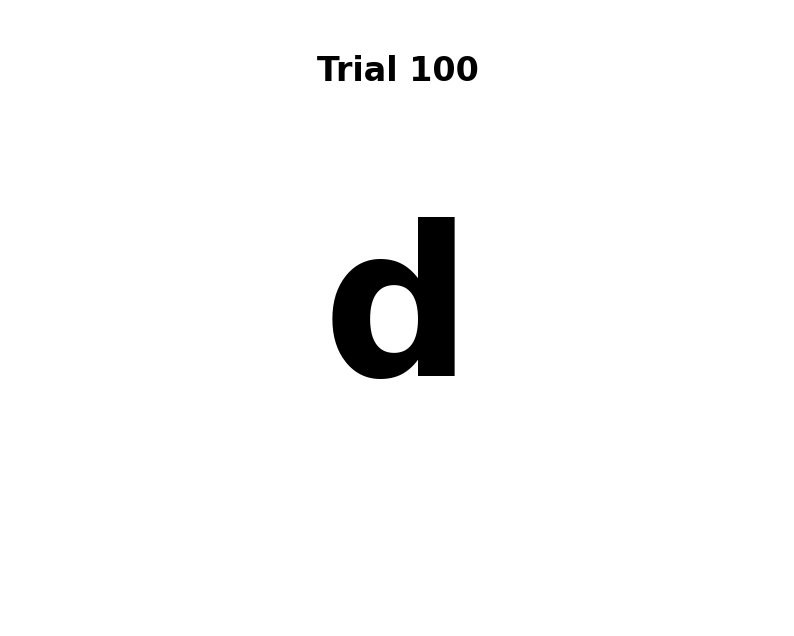

In [ ]:
anim, fig = create_target_char_animation(
    targetChar=TargetChar,
    interval=200,  # Milliseconds between frames
    save_path='neural_activity_animation_char.gif'  # Optional: save to file
)

# Display the animation
plt.show()